# Breast Radial **Kernel Bank** Optimization

This notebook applies the multi-kernel recipe from `brain2_radial_kernel.ipynb` to the breast
dataset that `radial_single_kernel_fi_optimization.ipynb` uses.

The only structural change versus the breast single-kernel notebook is the model:

| | single-kernel notebook | this notebook |
|---|---|---|
| kernels | one radial profile `f(r)` | `NUM_RADIAL_KERNELS` independent radial profiles |
| features | one scalar response | `mean_abs`, `abs_max`, `signed_topk` per kernel |
| head | scalar `w * feat + b` | small MLP during training, balanced logistic head for calibration |
| extra loss | smooth + anchor + scale | + curvature + a diversity term that pushes profiles apart |
| post-hoc | – | merge redundant kernels down to the smallest bank that keeps validation quality |

Everything else is kept identical to the breast baseline so the comparison is fair: same patch
folders, same `RESIZE_PATCH=128`, same patient-level splits, same seed kernel from
`composite_kernel.npy`, same threshold-tuning and metric code.

Workflow:
1. Build the rotation-invariant seed profile from the saved composite kernel.
2. Seed a bank of radial profiles from it (shifted/scaled variants + synthetic centre-surround shapes).
3. Fit the single-kernel seed baseline for reference, and print the best published single-kernel score.
4. Train the bank end-to-end, select the checkpoint on validation AUC, calibrate on train.
5. Full-image inference heatmap.
6. Merge redundant kernels into the minimal distinct set and re-check quality.

In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from scipy.ndimage import binary_erosion, gaussian_filter, rotate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from torch.utils.data import DataLoader, TensorDataset

from kernel_model.data import load_patches_from_folders, to_tensor_batch

# ------------------------------------------------------------------ data
EXP_DIR = Path("results/exp_022_mmr_nperFamily500_nComposition1250")
KERNEL_FILENAME = "composite_kernel.npy"
DATA_ROOT = None                 # None -> read data_root from EXP_DIR/config.json
TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT = "train", "val", "test"
RESIZE_PATCH = 128               # same as the single-kernel breast baseline
MAX_PER_CLASS = None

# ------------------------------------------------------------------ kernel bank
SEED_ROTATION_STEP_DEG = 10
LEARNED_RADIUS_MAX = 20          # same learned support as the r20 baseline
NUM_RADIAL_KERNELS = 16
SEED_BANK_SYNTHETIC_FRAC = 0.5   # share of the bank seeded from synthetic centre-surround shapes
BANK_SEED = 42

# ------------------------------------------------------------------ features / head
FEATURE_MODE = "multi"           # "multi" -> mean_abs + abs_max + signed_topk per kernel
RESPONSE_MODE = "signed_topk"    # used only when FEATURE_MODE == "single"
SIGNED_TOPK_FRAC = 0.01
STANDARDIZE_PATCHES = False      # baseline setting; per-patch standardization costs ~0.08 test AUC here
HEAD_HIDDEN_DIM = 32
HEAD_DROPOUT = 0.10

# ------------------------------------------------------------------ optimisation
EPOCHS = 25
BATCH_SIZE = 128
LR_PROFILE = 2e-3          # chosen on validation AUC over {1e-2, 2e-3, 5e-4}
LR_HEAD = 3e-3
LAMBDA_SMOOTH = 1e-4
LAMBDA_CURVATURE = 1e-4
LAMBDA_ANCHOR = 1e-4
LAMBDA_SCALE = 1e-4
LAMBDA_DIVERSITY = 1e-4
THRESHOLD_GRID_SIZE = 181

# ------------------------------------------------------------------ heatmap
EXAMPLE_IMAGE_PATH = Path("data/TIFF Images/malignantAnnotation/IMG015.tif")
EXACT_HEATMAP_STRIDE = 32        # breast TIFFs are ~6000x4750, so a coarse stride keeps this tractable
EXACT_HEATMAP_ROW_BLOCK = 8
EXACT_HEATMAP_BATCH_PATCHES = 128
EXACT_HEATMAP_MASK_THRESHOLD = 0.02
EXACT_HEATMAP_DISPLAY_PERCENTILE = 99.0
DENSE_OVERLAY_ALPHA = 0.40
HEATMAP_SMOOTH_SIGMA = 1.2
RUN_HEATMAP = True
SAVE_ARTIFACTS = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(min(8, max(1, os.cpu_count() or 1)))
torch.manual_seed(BANK_SEED)

OUT_DIR = EXP_DIR / f"radial_kernel_bank_k{NUM_RADIAL_KERNELS}_r{LEARNED_RADIUS_MAX}"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device: {DEVICE}")
print(f"Output dir: {OUT_DIR}")

Device: cuda
Output dir: results/exp_022_mmr_nperFamily500_nComposition1250/radial_kernel_bank_k16_r20


In [2]:
def resolve_data_root(exp_dir: Path, data_root_override):
    if data_root_override is not None:
        return Path(data_root_override)
    cfg_path = exp_dir / "config.json"
    if cfg_path.exists():
        cfg = json.loads(cfg_path.read_text())
        data_cfg = cfg.get("data", cfg)
        return Path(data_cfg.get("output_dir", cfg.get("data_root", "data/patches")))
    return Path("data/patches")


def load_split(root_dir: Path, split_name: str, resize_patch: int, max_per_class=None):
    Xin, Xout = load_patches_from_folders(
        root_dir,
        max_per_class=max_per_class,
        resize=(resize_patch, resize_patch),
        splits=(split_name,),
    )
    return Xin.astype(np.float32), Xout.astype(np.float32)


def integer_radius_bins(kernel_shape):
    h, w = kernel_shape
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
    yy, xx = np.indices((h, w))
    r = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    return np.floor(r).astype(np.int64)


def radial_profile_from_kernel(kernel2d: np.ndarray):
    radius_bins = integer_radius_bins(kernel2d.shape)
    max_r = int(radius_bins.max())
    radial_sum = np.bincount(radius_bins.ravel(), weights=kernel2d.ravel(), minlength=max_r + 1)
    radial_count = np.bincount(radius_bins.ravel(), minlength=max_r + 1)
    profile = radial_sum / np.maximum(radial_count, 1)
    return profile.astype(np.float32), radius_bins


def build_radial_basis(radius_bins: np.ndarray):
    max_r = int(radius_bins.max())
    return np.stack([(radius_bins == i).astype(np.float32) for i in range(max_r + 1)], axis=0).astype(np.float32)


def patch_standardize(x_t: torch.Tensor):
    mean = x_t.mean(dim=(2, 3), keepdim=True)
    std = x_t.std(dim=(2, 3), keepdim=True)
    std = torch.where(std < 1e-6, torch.ones_like(std), std)
    return (x_t - mean) / std


def make_xy_tensors(Xin_np: np.ndarray, Xout_np: np.ndarray, standardize: bool):
    X = np.concatenate([Xin_np, Xout_np], axis=0).astype(np.float32)
    y = np.concatenate([
        np.ones(len(Xin_np), dtype=np.float32),
        np.zeros(len(Xout_np), dtype=np.float32),
    ])
    X_t = to_tensor_batch(X, torch.device("cpu"))
    if standardize:
        X_t = patch_standardize(X_t)
    return X_t.contiguous(), torch.from_numpy(y).contiguous(), y.astype(np.int64)


def response_feature_names():
    if FEATURE_MODE == "multi":
        return ("mean_abs", "abs_max", "signed_topk")
    if FEATURE_MODE == "single":
        if RESPONSE_MODE not in {"mean_abs", "abs_max", "signed_topk"}:
            raise ValueError(f"Unknown RESPONSE_MODE={RESPONSE_MODE!r}")
        return (RESPONSE_MODE,)
    raise ValueError(f"Unknown FEATURE_MODE={FEATURE_MODE!r}")


RESPONSE_FEATURE_NAMES = response_feature_names()


def bank_response_features(x_t: torch.Tensor, kernels_t: torch.Tensor):
    """[B, K*len(features)] pooled responses of a whole radial-kernel bank."""
    conv = F.conv2d(x_t, kernels_t[:, None], padding=kernels_t.shape[-1] // 2)
    flat = conv.flatten(start_dim=2)
    feats = []
    for name in RESPONSE_FEATURE_NAMES:
        if name == "mean_abs":
            feats.append(conv.abs().mean(dim=(2, 3)))
        elif name == "abs_max":
            feats.append(conv.abs().amax(dim=(2, 3)))
        elif name == "signed_topk":
            k_top = max(1, int(round(flat.shape[-1] * float(SIGNED_TOPK_FRAC))))
            pos = flat.topk(k_top, dim=2).values.mean(dim=2)
            neg = (-flat).topk(k_top, dim=2).values.mean(dim=2)
            feats.append(pos - neg)
        else:
            raise ValueError(f"Unknown response feature {name!r}")
    return torch.cat(feats, dim=1)


@torch.no_grad()
def extract_bank_features(x_t: torch.Tensor, kernels_t: torch.Tensor, batch_size: int):
    kernels_t = kernels_t.to(DEVICE)
    n_feat = int(kernels_t.shape[0]) * len(RESPONSE_FEATURE_NAMES)
    feats = []
    for i in range(0, x_t.shape[0], batch_size):
        xb = x_t[i : i + batch_size].to(DEVICE, non_blocking=True)
        feats.append(bank_response_features(xb, kernels_t).detach().cpu().numpy())
    return np.concatenate(feats, axis=0).astype(np.float32) if feats else np.zeros((0, n_feat), dtype=np.float32)


def response_from_kernel(x_t: torch.Tensor, kernel2d_t: torch.Tensor, mode: str):
    out = F.conv2d(x_t, kernel2d_t[None, None], padding=kernel2d_t.shape[-1] // 2)
    if mode == "abs_max":
        return out.abs().amax(dim=(2, 3))[:, 0]
    if mode == "mean_abs":
        return out.abs().mean(dim=(2, 3))[:, 0]
    raise ValueError(f"Unknown response mode '{mode}'")


@torch.no_grad()
def extract_responses(x_t: torch.Tensor, kernel2d_t: torch.Tensor, batch_size: int, mode: str = "abs_max"):
    kernel2d_t = kernel2d_t.to(DEVICE)
    feats = []
    for i in range(0, x_t.shape[0], batch_size):
        xb = x_t[i : i + batch_size].to(DEVICE, non_blocking=True)
        feats.append(response_from_kernel(xb, kernel2d_t, mode).detach().cpu().numpy())
    return np.concatenate(feats, axis=0) if feats else np.zeros((0,), dtype=np.float32)


def metrics_from_probs(y_true: np.ndarray, probs: np.ndarray, threshold: float = 0.5):
    y_hat = (probs > float(threshold)).astype(np.int64)
    acc = accuracy_score(y_true, y_hat)
    auc = roc_auc_score(y_true, probs) if len(np.unique(y_true)) > 1 else float("nan")
    return {"acc": float(acc), "auc": float(auc)}


def best_threshold_by_accuracy(y_true: np.ndarray, probs: np.ndarray, grid_size: int = 181):
    grid = np.linspace(0.05, 0.95, int(grid_size), dtype=np.float32)
    preds = probs[None, :] > grid[:, None]
    accs = (preds == y_true[None, :]).mean(axis=1)
    best_idx = int(np.argmax(accs))
    return float(grid[best_idx]), float(accs[best_idx])


def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))


def ensure_example_image(path: Path):
    path = Path(path)
    if path.exists():
        return path
    candidates = sorted(Path("data/TIFF Images/malignantAnnotation").glob("*.tif"))
    if not candidates:
        raise FileNotFoundError("Could not find example image and no fallback TIFFs under malignantAnnotation.")
    return candidates[0]


print(f"Response features per kernel: {RESPONSE_FEATURE_NAMES}")

Response features per kernel: ('mean_abs', 'abs_max', 'signed_topk')


Composite kernel shape: (31, 31)
Rotation-invariant seed from 36 angles (step 10 deg)
Total radial shells: 22  |  learnable shells: 0..20
Frozen outer shells: 21..21
Seed bank: 16 profiles of length 21


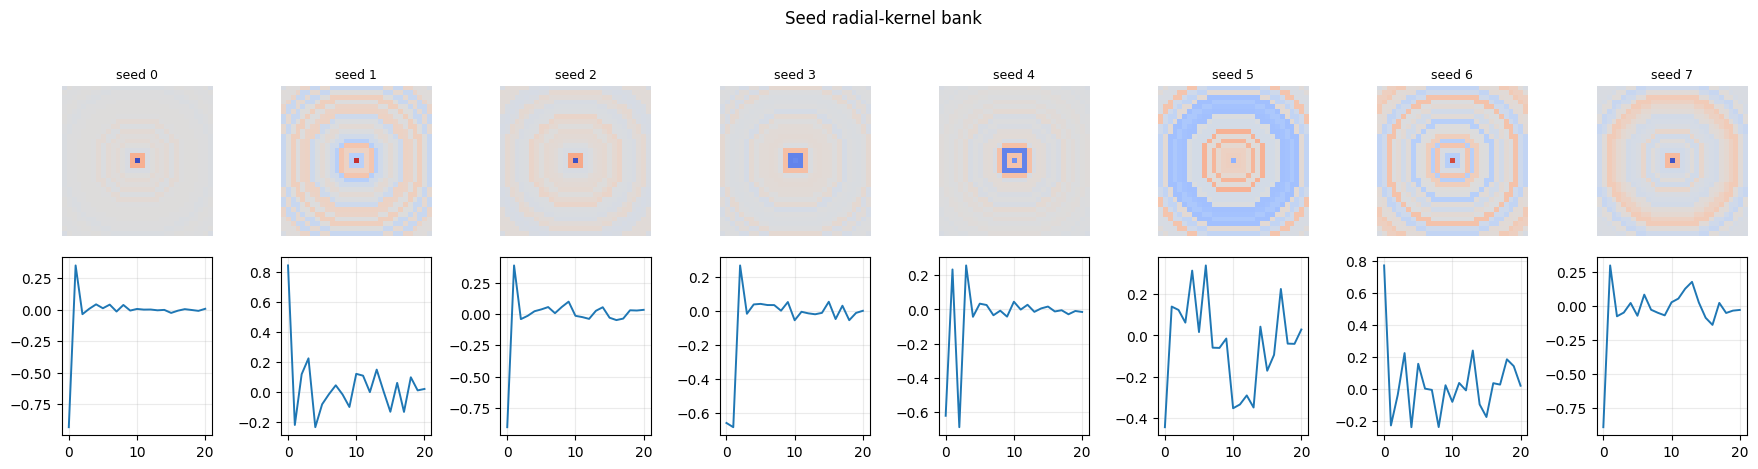

In [3]:
kernel_path = EXP_DIR / KERNEL_FILENAME
if not kernel_path.exists():
    raise FileNotFoundError(f"Missing kernel file: {kernel_path}")

base_kernel = np.load(kernel_path).astype(np.float32)
if base_kernel.ndim != 2:
    raise ValueError(f"Expected a 2D kernel, got shape={base_kernel.shape}")

rotated_kernels = [
    rotate(base_kernel, angle=angle, reshape=False, order=1, mode="nearest", prefilter=False)
    for angle in range(0, 360, SEED_ROTATION_STEP_DEG)
]
rotation_invariant_kernel = np.mean(np.stack(rotated_kernels, axis=0), axis=0).astype(np.float32)

f_seed_raw, radius_bins = radial_profile_from_kernel(rotation_invariant_kernel)
basis_np = build_radial_basis(radius_bins)
basis_t = torch.from_numpy(basis_np).to(DEVICE)
full_radius_count = len(f_seed_raw)

# The composite profile has norm ~2.5e-3. Rescaling it to unit norm leaves the classifier
# unchanged (the head absorbs any scalar), but it puts the seed, the bank perturbations and the
# regularization weights on one common scale.
seed_scale = float(np.linalg.norm(f_seed_raw))
f_seed_full = (f_seed_raw / seed_scale).astype(np.float32) if seed_scale > 1e-12 else f_seed_raw
seed_radial_kernel = np.einsum("r,rhw->hw", f_seed_full, basis_np).astype(np.float32)

learnable_len = min(int(LEARNED_RADIUS_MAX), full_radius_count - 1) + 1
f_seed_learn = f_seed_full[:learnable_len].copy()
f_tail_fixed = f_seed_full[learnable_len:].copy()
f_tail_fixed_t = torch.from_numpy(f_tail_fixed).to(DEVICE)
seed_norm = float(np.linalg.norm(f_seed_full))


def make_synthetic_profile(center_sigma: float, surround_radius: float, surround_sigma: float, surround_gain: float):
    """Smooth signed centre-surround shape, zeroed beyond the learned support and unit-normalized."""
    r = np.arange(learnable_len, dtype=np.float32)
    profile = np.exp(-(r / float(center_sigma)) ** 2)
    profile = profile - float(surround_gain) * np.exp(-((r - float(surround_radius)) / float(surround_sigma)) ** 2)
    norm = float(np.linalg.norm(profile))
    return (profile / norm).astype(np.float32) if norm > 1e-8 else profile.astype(np.float32)


def make_seed_bank(n_kernels: int):
    """Bank seeds: the composite profile, shifted/scaled variants of it, and synthetic shapes.

    The composite seed is extremely compact (essentially r=0..1), so variants of it alone would all
    live in the same tiny corner of profile space. The synthetic centre-surround family gives the
    bank genuinely different spatial scales to start from.
    """
    rng = np.random.default_rng(BANK_SEED)
    n_synth = int(round(float(SEED_BANK_SYNTHETIC_FRAC) * n_kernels))
    n_variant = n_kernels - n_synth
    profiles = [f_seed_learn.astype(np.float32)]

    for k in range(1, n_variant):
        shift = int((k % 5) - 2)
        scale = 0.75 + 0.10 * (k % 6)
        variant = np.roll(f_seed_learn, shift) * scale
        variant = variant + rng.normal(0.0, 0.05, size=variant.shape).astype(np.float32)
        if shift > 0:
            variant[:shift] = f_seed_learn[:shift]
        elif shift < 0:
            variant[shift:] = f_seed_learn[shift:]
        norm = float(np.linalg.norm(variant))
        profiles.append((variant / norm).astype(np.float32) if norm > 1e-8 else variant.astype(np.float32))

    for k in range(n_synth):
        center_sigma = 1.5 + 1.5 * k
        surround_radius = 2.0 * center_sigma
        surround_sigma = max(1.5, center_sigma)
        surround_gain = 0.35 + 0.10 * (k % 4)
        synth = make_synthetic_profile(center_sigma, surround_radius, surround_sigma, surround_gain)
        synth = synth + rng.normal(0.0, 0.02, size=synth.shape).astype(np.float32)
        norm = float(np.linalg.norm(synth))
        profiles.append((synth / norm).astype(np.float32) if norm > 1e-8 else synth.astype(np.float32))

    return np.stack(profiles[:n_kernels], axis=0).astype(np.float32)


f_seed_bank = make_seed_bank(int(NUM_RADIAL_KERNELS))
f_seed_bank_t = torch.from_numpy(f_seed_bank).to(DEVICE)


def build_kernels(f_bank_t: torch.Tensor):
    """Expand [K, learnable_len] profiles into [K, H, W] radial kernels (frozen outer shells appended)."""
    if f_tail_fixed_t.numel() > 0:
        tail = f_tail_fixed_t[None, :].expand(f_bank_t.shape[0], -1)
        f_full_t = torch.cat([f_bank_t, tail], dim=1)
    else:
        f_full_t = f_bank_t
    return torch.einsum("kr,rhw->khw", f_full_t, basis_t), f_full_t


with torch.no_grad():
    seed_kernels_t, _ = build_kernels(f_seed_bank_t)
seed_kernels_np = seed_kernels_t.detach().cpu().numpy().astype(np.float32)

print(f"Composite kernel shape: {base_kernel.shape}")
print(f"Rotation-invariant seed from {len(rotated_kernels)} angles (step {SEED_ROTATION_STEP_DEG} deg)")
print(f"Total radial shells: {full_radius_count}  |  learnable shells: 0..{learnable_len - 1}")
print(f"Frozen outer shells: {learnable_len}..{full_radius_count - 1}")
print(f"Seed bank: {f_seed_bank.shape[0]} profiles of length {f_seed_bank.shape[1]}")

n_show = min(int(NUM_RADIAL_KERNELS), 8)
fig, axes = plt.subplots(2, n_show, figsize=(2.2 * n_show, 4.6))
if n_show == 1:
    axes = np.array(axes).reshape(2, 1)
vmax = float(np.max(np.abs(seed_kernels_np))) + 1e-12
for k in range(n_show):
    axes[0, k].imshow(seed_kernels_np[k], cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axes[0, k].set_title(f"seed {k}", fontsize=9)
    axes[0, k].axis("off")
    axes[1, k].plot(np.arange(f_seed_bank.shape[1]), f_seed_bank[k], linewidth=1.4)
    axes[1, k].grid(alpha=0.25)
fig.suptitle("Seed radial-kernel bank", y=1.01)
plt.tight_layout()
plt.show()

In [4]:
data_root = resolve_data_root(EXP_DIR, DATA_ROOT)
print(f"Data root: {data_root}")

Xin_train, Xout_train = load_split(data_root, TRAIN_SPLIT, RESIZE_PATCH, MAX_PER_CLASS)
Xin_val, Xout_val = load_split(data_root, VAL_SPLIT, RESIZE_PATCH, MAX_PER_CLASS)
Xin_test, Xout_test = load_split(data_root, TEST_SPLIT, RESIZE_PATCH, MAX_PER_CLASS)

X_train_t, y_train_t, y_train = make_xy_tensors(Xin_train, Xout_train, STANDARDIZE_PATCHES)
X_val_t, y_val_t, y_val = make_xy_tensors(Xin_val, Xout_val, STANDARDIZE_PATCHES)
X_test_t, y_test_t, y_test = make_xy_tensors(Xin_test, Xout_test, STANDARDIZE_PATCHES)


def print_split_balance(name: str, y: np.ndarray):
    counts = np.bincount(y, minlength=2)
    neg, pos = int(counts[0]), int(counts[1])
    majority = max(neg, pos) / max(1, neg + pos)
    print(f"  {name:5s} neg={neg:5d} pos={pos:5d} majority_baseline={majority:.3f}")
    if neg == 0 or pos == 0:
        raise ValueError(f"{name} split has an empty class: neg={neg}, pos={pos}")


print("Patch tensors:")
for name, t in (("train", X_train_t), ("val", X_val_t), ("test", X_test_t)):
    print(f"  {name:5s} {tuple(t.shape)}")
print("Class balance:")
print_split_balance("train", y_train)
print_split_balance("val", y_val)
print_split_balance("test", y_test)

# ---- single-kernel seed baseline, same code path as the breast baseline notebook -------------
seed_kernel_t = torch.from_numpy(seed_radial_kernel).to(DEVICE)
seed_train_resp = extract_responses(X_train_t, seed_kernel_t, BATCH_SIZE, "abs_max")
seed_val_resp = extract_responses(X_val_t, seed_kernel_t, BATCH_SIZE, "abs_max")
seed_test_resp = extract_responses(X_test_t, seed_kernel_t, BATCH_SIZE, "abs_max")

seed_mu = float(seed_train_resp.mean())
seed_std = float(seed_train_resp.std()) or 1.0
seed_clf = LogisticRegression(max_iter=1000)
seed_clf.fit(((seed_train_resp - seed_mu) / seed_std).reshape(-1, 1), y_train)
seed_probs_val = seed_clf.predict_proba(((seed_val_resp - seed_mu) / seed_std).reshape(-1, 1))[:, 1]
seed_probs_test = seed_clf.predict_proba(((seed_test_resp - seed_mu) / seed_std).reshape(-1, 1))[:, 1]
seed_threshold_val, _ = best_threshold_by_accuracy(y_val, seed_probs_val, THRESHOLD_GRID_SIZE)

seed_results = {
    "val_05": metrics_from_probs(y_val, seed_probs_val, 0.5),
    "val_tuned": metrics_from_probs(y_val, seed_probs_val, seed_threshold_val),
    "test_05": metrics_from_probs(y_test, seed_probs_test, 0.5),
    "test_tuned": metrics_from_probs(y_test, seed_probs_test, seed_threshold_val),
    "threshold_val": float(seed_threshold_val),
}
print("\nSingle-kernel seed baseline (abs_max response):")
print(f"  Val  | AUC={seed_results['val_05']['auc']:.6f} ACC@0.5={seed_results['val_05']['acc']:.6f}")
print(f"  Test | AUC={seed_results['test_05']['auc']:.6f} ACC@0.5={seed_results['test_05']['acc']:.6f} "
      f"ACC@thr_val={seed_results['test_tuned']['acc']:.6f}")


# ---- best previously published single-kernel result, read straight from its saved summaries ---
def best_published_single_kernel(root: Path):
    keys = ("learned", "learned_monotone", "learned_signed", "learned_scratch",
            "learned_free", "learned_radius", "seed")
    best = None
    for path in sorted(Path(root).rglob("*.json")):
        try:
            payload = json.loads(path.read_text())
        except Exception:
            continue
        for key in keys:
            entry = payload.get(key)
            if not isinstance(entry, dict) or "test_05" not in entry:
                continue
            row = {
                "source": f"{path.parent.name}/{path.name}:{key}",
                "val_auc": float(entry["val_05"]["auc"]),
                "test_auc": float(entry["test_05"]["auc"]),
                "test_acc": float(entry["test_05"]["acc"]),
                "test_acc_tuned": float(entry["test_tuned"]["acc"]),
            }
            if best is None or row["test_auc"] > best["test_auc"]:
                best = row
    return best


SINGLE_KERNEL_ROOT = EXP_DIR / f"radial_single_kernel_r{LEARNED_RADIUS_MAX}"
single_kernel_best = best_published_single_kernel(SINGLE_KERNEL_ROOT) if SINGLE_KERNEL_ROOT.exists() else None
if single_kernel_best is not None:
    print("\nBar to beat -- best saved single-kernel run under "
          f"{SINGLE_KERNEL_ROOT}:")
    print(f"  {single_kernel_best['source']}")
    print(f"  val AUC={single_kernel_best['val_auc']:.4f} test AUC={single_kernel_best['test_auc']:.4f} "
          f"test ACC@0.5={single_kernel_best['test_acc']:.4f} test ACC@thr={single_kernel_best['test_acc_tuned']:.4f}")
else:
    print(f"\nNo saved single-kernel summaries found under {SINGLE_KERNEL_ROOT}")

Data root: data/patches


Patch tensors:
  train (6330, 1, 128, 128)
  val   (1870, 1, 128, 128)
  test  (1870, 1, 128, 128)
Class balance:
  train neg= 3430 pos= 2900 majority_baseline=0.542
  val   neg=  790 pos= 1080 majority_baseline=0.578
  test  neg=  830 pos= 1040 majority_baseline=0.556



Single-kernel seed baseline (abs_max response):
  Val  | AUC=0.889848 ACC@0.5=0.818182
  Test | AUC=0.882470 ACC@0.5=0.800000 ACC@thr_val=0.802139

Bar to beat -- best saved single-kernel run under results/exp_022_mmr_nperFamily500_nComposition1250/radial_single_kernel_r20:
  monotone_decreasing/monotone_summary.json:learned_monotone
  val AUC=0.9100 test AUC=0.9212 test ACC@0.5=0.8524 test ACC@thr=0.8412


In [5]:
# =====================================================================
# Radial-kernel BANK training.
#
# The model stays radial: every kernel is still a function of radius alone. What changes versus
# the single-kernel notebook is that K profiles are learned jointly and a small MLP reads all of
# their pooled responses, so the bank can encode several tissue scales instead of one detector.
# =====================================================================
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)

f_bank = torch.nn.Parameter(f_seed_bank_t.clone())

# Feature normalization is fixed at the seed bank so the optimizer sees a stable input scale.
opt_feat_ref = extract_bank_features(X_train_t, seed_kernels_t.detach(), BATCH_SIZE)
opt_feat_mu = opt_feat_ref.mean(axis=0).astype(np.float32)
opt_feat_std = opt_feat_ref.std(axis=0).astype(np.float32)
opt_feat_std = np.where(opt_feat_std > 1e-8, opt_feat_std, 1.0).astype(np.float32)
opt_feat_mu_t = torch.from_numpy(opt_feat_mu).to(DEVICE)
opt_feat_std_t = torch.from_numpy(opt_feat_std).to(DEVICE)
print(f"Optimizer features: {opt_feat_ref.shape[1]} = {NUM_RADIAL_KERNELS} kernels x {len(RESPONSE_FEATURE_NAMES)} pooled responses")

head = torch.nn.Sequential(
    torch.nn.Linear(opt_feat_ref.shape[1], int(HEAD_HIDDEN_DIM)),
    torch.nn.ReLU(),
    torch.nn.Dropout(float(HEAD_DROPOUT)),
    torch.nn.Linear(int(HEAD_HIDDEN_DIM), 1),
).to(DEVICE)

optimizer = torch.optim.Adam([
    {"params": [f_bank], "lr": LR_PROFILE},
    {"params": head.parameters(), "lr": LR_HEAD},
])

n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
pos_weight = torch.tensor([n_neg / max(1, n_pos)], dtype=torch.float32, device=DEVICE)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f"BCE pos_weight={float(pos_weight.cpu()[0]):.3f}")

best_state = None
best_val_auc = -float("inf")
history = []

for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0
    total_cls_loss = 0.0
    n_seen = 0
    head.train()
    for xb, yb in train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        kernels_t, f_full_t = build_kernels(f_bank)
        feat = (bank_response_features(xb, kernels_t) - opt_feat_mu_t) / opt_feat_std_t
        logits = head(feat).squeeze(1)
        loss_cls = loss_fn(logits, yb)

        loss_smooth = torch.mean((f_full_t[:, 1:] - f_full_t[:, :-1]) ** 2)
        loss_curvature = torch.mean((f_full_t[:, 2:] - 2.0 * f_full_t[:, 1:-1] + f_full_t[:, :-2]) ** 2)
        loss_anchor = torch.mean((f_bank - f_seed_bank_t) ** 2)
        loss_scale = torch.mean((torch.linalg.norm(f_full_t, dim=1) - seed_norm) ** 2)
        loss_diversity = (
            torch.mean(torch.exp(-torch.pdist(f_bank, p=2).pow(2)))
            if f_bank.shape[0] > 1
            else torch.tensor(0.0, device=DEVICE)
        )
        loss = (
            loss_cls
            + LAMBDA_SMOOTH * loss_smooth
            + LAMBDA_CURVATURE * loss_curvature
            + LAMBDA_ANCHOR * loss_anchor
            + LAMBDA_SCALE * loss_scale
            + LAMBDA_DIVERSITY * loss_diversity
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_n = xb.shape[0]
        total_loss += float(loss.item()) * batch_n
        total_cls_loss += float(loss_cls.item()) * batch_n
        n_seen += batch_n

    head.eval()
    with torch.no_grad():
        kernels_eval_t, _ = build_kernels(f_bank)
        val_feat = (extract_bank_features(X_val_t, kernels_eval_t.detach(), BATCH_SIZE) - opt_feat_mu) / opt_feat_std
        val_logits = head(torch.from_numpy(val_feat).to(DEVICE)).squeeze(1).detach().cpu().numpy()
        val_metrics = metrics_from_probs(y_val, sigmoid_np(val_logits), 0.5)

    row = {
        "epoch": int(epoch),
        "loss": float(total_loss / max(n_seen, 1)),
        "cls_loss": float(total_cls_loss / max(n_seen, 1)),
        "val_auc": float(val_metrics["auc"]),
        "val_acc": float(val_metrics["acc"]),
    }
    history.append(row)

    if row["val_auc"] > best_val_auc:
        best_val_auc = row["val_auc"]
        best_state = {
            "epoch": int(epoch),
            "f_bank": f_bank.detach().cpu().clone(),
            "head_state": {k: v.detach().cpu().clone() for k, v in head.state_dict().items()},
            "val_auc": row["val_auc"],
            "val_acc": row["val_acc"],
        }

    print(f"epoch={epoch:02d} loss={row['loss']:.6f} cls={row['cls_loss']:.6f} "
          f"val_auc={row['val_auc']:.6f} val_acc={row['val_acc']:.6f}")

print("\nBest checkpoint:")
print({k: v for k, v in best_state.items() if k not in {"head_state", "f_bank"}})

f_bank_best = best_state["f_bank"].to(DEVICE)
head.load_state_dict(best_state["head_state"])
head.to(DEVICE).eval()
with torch.no_grad():
    kernels_best_t, f_best_full_t = build_kernels(f_bank_best)

f_best_full = f_best_full_t.detach().cpu().numpy().astype(np.float32)
kernel_best = kernels_best_t.detach().cpu().numpy().astype(np.float32)

# ---- balanced logistic calibration on the learned bank ---------------------------------------
train_feat = extract_bank_features(X_train_t, kernels_best_t.detach(), BATCH_SIZE)
val_feat = extract_bank_features(X_val_t, kernels_best_t.detach(), BATCH_SIZE)
test_feat = extract_bank_features(X_test_t, kernels_best_t.detach(), BATCH_SIZE)

calib_mu = train_feat.mean(axis=0).astype(np.float32)
calib_std = train_feat.std(axis=0).astype(np.float32)
calib_std = np.where(calib_std > 1e-8, calib_std, 1.0).astype(np.float32)

calib_clf = LogisticRegression(max_iter=2000, class_weight="balanced")
calib_clf.fit((train_feat - calib_mu) / calib_std, y_train)
calib_w = calib_clf.coef_[0].astype(np.float32)
calib_b = float(calib_clf.intercept_[0])

train_probs = calib_clf.predict_proba((train_feat - calib_mu) / calib_std)[:, 1]
val_probs = calib_clf.predict_proba((val_feat - calib_mu) / calib_std)[:, 1]
test_probs = calib_clf.predict_proba((test_feat - calib_mu) / calib_std)[:, 1]

threshold_val, _ = best_threshold_by_accuracy(y_val, val_probs, THRESHOLD_GRID_SIZE)
results = {
    "train_05": metrics_from_probs(y_train, train_probs, 0.5),
    "val_05": metrics_from_probs(y_val, val_probs, 0.5),
    "val_tuned": metrics_from_probs(y_val, val_probs, threshold_val),
    "test_05": metrics_from_probs(y_test, test_probs, 0.5),
    "test_tuned": metrics_from_probs(y_test, test_probs, threshold_val),
    "threshold_val": float(threshold_val),
    "best_epoch": int(best_state["epoch"]),
    "num_radial_kernels": int(NUM_RADIAL_KERNELS),
    "response_feature_names": list(RESPONSE_FEATURE_NAMES),
    "calib_mu": [float(x) for x in calib_mu],
    "calib_std": [float(x) for x in calib_std],
    "calib_w": [float(x) for x in calib_w],
    "calib_b": calib_b,
}

print("\nCalibrated radial-kernel bank metrics:")
print(f"  Train| AUC={results['train_05']['auc']:.6f} ACC@0.5={results['train_05']['acc']:.6f}")
print(f"  Val  | AUC={results['val_05']['auc']:.6f} ACC@0.5={results['val_05']['acc']:.6f} "
      f"ACC@thr_val={results['val_tuned']['acc']:.6f} (thr_val={results['threshold_val']:.3f})")
print(f"  Test | AUC={results['test_05']['auc']:.6f} ACC@0.5={results['test_05']['acc']:.6f} "
      f"ACC@thr_val={results['test_tuned']['acc']:.6f}")

if single_kernel_best is not None:
    print("\nVersus best saved single-kernel run:")
    print(f"{'metric':<16}{'single':>10}{'bank':>10}{'delta':>10}")
    for label, single_v, bank_v in (
        ("test AUC", single_kernel_best["test_auc"], results["test_05"]["auc"]),
        ("test ACC@0.5", single_kernel_best["test_acc"], results["test_05"]["acc"]),
        ("test ACC@thr", single_kernel_best["test_acc_tuned"], results["test_tuned"]["acc"]),
        ("val AUC", single_kernel_best["val_auc"], results["val_05"]["auc"]),
    ):
        print(f"{label:<16}{single_v:>10.4f}{bank_v:>10.4f}{bank_v - single_v:>+10.4f}")

feature_labels = [f"k{k:02d}:{name}" for name in RESPONSE_FEATURE_NAMES for k in range(int(NUM_RADIAL_KERNELS))]
print("\nTop calibration weights:")
for idx in np.argsort(np.abs(calib_w))[::-1][:12]:
    print(f"  {feature_labels[idx]:16s} w={float(calib_w[idx]):+.4f} "
          f"mu={float(calib_mu[idx]):+.5f} std={float(calib_std[idx]):.5f}")

Optimizer features: 48 = 16 kernels x 3 pooled responses


BCE pos_weight=1.183


epoch=01 loss=0.455515 cls=0.455474 val_auc=0.927296 val_acc=0.863636


epoch=02 loss=0.407854 cls=0.407813 val_auc=0.926288 val_acc=0.851872


epoch=03 loss=0.408602 cls=0.408562 val_auc=0.925708 val_acc=0.863636


...

epoch=22 loss=0.387756 cls=0.387715 val_auc=0.926008 val_acc=0.849198


epoch=23 loss=0.385189 cls=0.385148 val_auc=0.925993 val_acc=0.869519


epoch=24 loss=0.380089 cls=0.380049 val_auc=0.926448 val_acc=0.872193


epoch=25 loss=0.383367 cls=0.383326 val_auc=0.926296 val_acc=0.856150

Best checkpoint:
{'epoch': 1, 'val_auc': 0.9272960618846695, 'val_acc': 0.8636363636363636}



Calibrated radial-kernel bank metrics:
  Train| AUC=0.927097 ACC@0.5=0.862085
  Val  | AUC=0.938835 ACC@0.5=0.886096 ACC@thr_val=0.891444 (thr_val=0.440)
  Test | AUC=0.941072 ACC@0.5=0.875401 ACC@thr_val=0.874866

Versus best saved single-kernel run:
metric              single      bank     delta
test AUC            0.9212    0.9411   +0.0199
test ACC@0.5        0.8524    0.8754   +0.0230
test ACC@thr        0.8412    0.8749   +0.0337
val AUC             0.9100    0.9388   +0.0288

Top calibration weights:
  k00:signed_topk  w=+3.5058 mu=+2.02389 std=0.56571
  k02:signed_topk  w=-2.8497 mu=+15.80755 std=4.50806
  k01:signed_topk  w=+2.8472 mu=+8.51470 std=2.43429
  k13:mean_abs     w=-2.7694 mu=+6.06729 std=1.85019
  k15:signed_topk  w=-2.3803 mu=+55.80526 std=15.70525
  k13:abs_max      w=-1.7265 mu=+24.68811 std=6.60894
  k03:signed_topk  w=-1.5701 mu=-1.99184 std=0.55380
  k00:mean_abs     w=-1.1833 mu=+0.93334 std=0.30095
  k14:abs_max      w=-1.1772 mu=+34.89875 std=9.26892
  k0

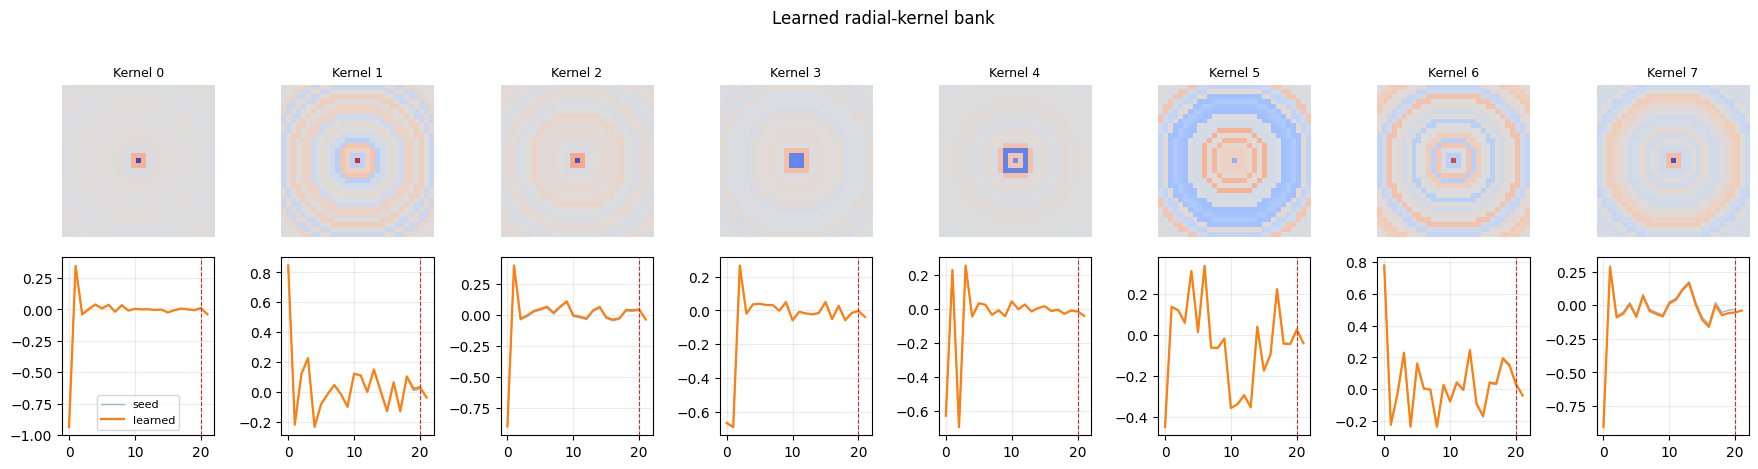

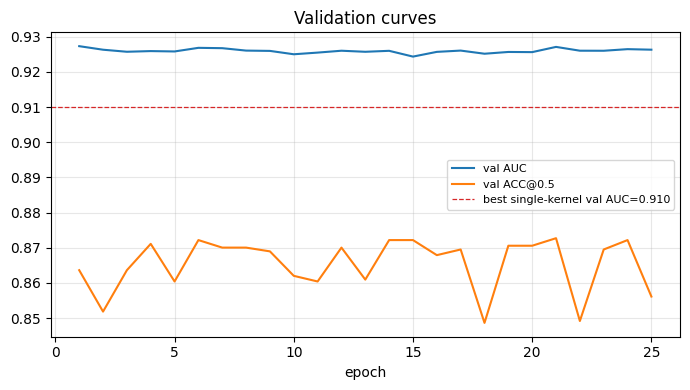

Saved radial-kernel bank artifacts to results/exp_022_mmr_nperFamily500_nComposition1250/radial_kernel_bank_k16_r20


In [6]:
n_show = min(int(NUM_RADIAL_KERNELS), 8)
fig, axes = plt.subplots(2, n_show, figsize=(2.2 * n_show, 4.6))
if n_show == 1:
    axes = np.array(axes).reshape(2, 1)
vmax = float(np.max(np.abs(kernel_best))) + 1e-12
for k in range(n_show):
    axes[0, k].imshow(kernel_best[k], cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axes[0, k].set_title(f"Kernel {k}", fontsize=9)
    axes[0, k].axis("off")
    axes[1, k].plot(np.arange(f_seed_bank.shape[1]), f_seed_bank[k], linewidth=1.0, alpha=0.5, label="seed")
    axes[1, k].plot(np.arange(f_best_full.shape[1]), f_best_full[k], linewidth=1.6, label="learned")
    axes[1, k].axvline(learnable_len - 1, color="tab:red", linestyle="--", linewidth=0.8)
    axes[1, k].grid(alpha=0.25)
    if k == 0:
        axes[1, k].legend(fontsize=8)
fig.suptitle("Learned radial-kernel bank", y=1.01)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
hist_epochs = [row["epoch"] for row in history]
ax.plot(hist_epochs, [row["val_auc"] for row in history], label="val AUC")
ax.plot(hist_epochs, [row["val_acc"] for row in history], label="val ACC@0.5")
if single_kernel_best is not None:
    ax.axhline(single_kernel_best["val_auc"], color="tab:red", ls="--", lw=0.9,
               label=f"best single-kernel val AUC={single_kernel_best['val_auc']:.3f}")
ax.set_xlabel("epoch")
ax.set_title("Validation curves")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

if SAVE_ARTIFACTS:
    np.save(OUT_DIR / "kernels_seed_radial_bank.npy", seed_kernels_np)
    np.save(OUT_DIR / "kernels_learned_radial_bank.npy", kernel_best)
    np.save(OUT_DIR / "f_seed_bank.npy", f_seed_bank)
    np.save(OUT_DIR / "f_learned_full_bank.npy", f_best_full)
    summary = {
        "config": {
            "exp_dir": str(EXP_DIR),
            "data_root": str(data_root),
            "resize_patch": int(RESIZE_PATCH),
            "kernel_size": list(base_kernel.shape),
            "learned_radius_max": int(LEARNED_RADIUS_MAX),
            "num_radial_kernels": int(NUM_RADIAL_KERNELS),
            "feature_mode": FEATURE_MODE,
            "response_feature_names": list(RESPONSE_FEATURE_NAMES),
            "standardize_patches": bool(STANDARDIZE_PATCHES),
            "epochs": int(EPOCHS),
            "batch_size": int(BATCH_SIZE),
        },
        "seed_profile_unit_norm": [float(x) for x in f_seed_full],
        "seed_profile_scale": float(seed_scale),
        "seed_bank": [[float(x) for x in row] for row in f_seed_bank],
        "learned_profiles": [[float(x) for x in row] for row in f_best_full],
        "seed_single_kernel_metrics": seed_results,
        "best_published_single_kernel": single_kernel_best,
        "metrics": results,
        "history": history,
    }
    (OUT_DIR / "radial_kernel_bank_summary.json").write_text(json.dumps(summary, indent=2))
    print(f"Saved radial-kernel bank artifacts to {OUT_DIR}")

Rendering bank heatmap for data/TIFF Images/malignantAnnotation/IMG015.tif (stride=32)


  rows 8/188


  rows 16/188


  rows 24/188


  rows 32/188


...

  rows 160/188


  rows 168/188


  rows 176/188


  rows 184/188


  rows 188/188


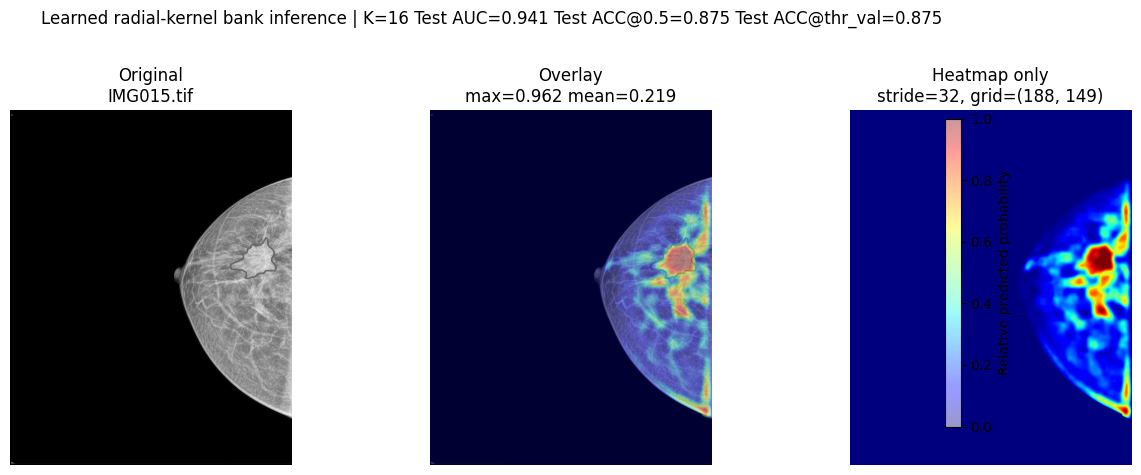

Saved bank heatmap artifacts to results/exp_022_mmr_nperFamily500_nComposition1250/radial_kernel_bank_k16_r20


In [7]:
# =====================================================================
# Full-image inference heatmap for the learned bank.
#
# The bank features are patch-level pooled statistics, so the correct inference path is a sliding
# patch grid, not a single dense convolution. Patches are cut with F.unfold in row blocks and
# scored with exactly the classifier that was calibrated above.
# =====================================================================
@torch.no_grad()
def exact_bank_feature_grid(image_np, kernels_np, patch_size, stride, batch_patches, row_block):
    image_t = to_tensor_batch(image_np[None, ...].astype(np.float32), torch.device("cpu"))
    h, w = image_np.shape

    pad_top = patch_size // 2
    pad_left = patch_size // 2
    padded = F.pad(image_t, (pad_left, patch_size - pad_left - 1, pad_top, patch_size - pad_top - 1),
                   mode="constant", value=0.0)

    y_positions = list(range(0, h, stride))
    x_positions = list(range(0, w, stride))
    kernels_t = torch.from_numpy(np.asarray(kernels_np, dtype=np.float32)).to(DEVICE)
    n_feat = int(kernels_t.shape[0]) * len(RESPONSE_FEATURE_NAMES)
    feat_grid = np.zeros((len(y_positions), len(x_positions), n_feat), dtype=np.float32)

    for row_start in range(0, len(y_positions), row_block):
        block_rows = y_positions[row_start : row_start + row_block]
        crop_h = (len(block_rows) - 1) * stride + patch_size
        crop = padded[:, :, block_rows[0] : block_rows[0] + crop_h, :]

        patches = F.unfold(crop, kernel_size=(patch_size, patch_size), stride=(stride, stride))
        patches = patches.transpose(1, 2).reshape(-1, 1, patch_size, patch_size).contiguous()
        if STANDARDIZE_PATCHES:
            patches = patch_standardize(patches)

        block_feats = []
        for i in range(0, patches.shape[0], batch_patches):
            pb = patches[i : i + batch_patches].to(DEVICE, non_blocking=True)
            block_feats.append(bank_response_features(pb, kernels_t).detach().cpu().numpy())
        block_feats = np.concatenate(block_feats, axis=0).astype(np.float32)
        feat_grid[row_start : row_start + len(block_rows)] = block_feats.reshape(
            len(block_rows), len(x_positions), n_feat
        )
        print(f"  rows {row_start + len(block_rows)}/{len(y_positions)}", flush=True)

    return feat_grid


def render_bank_heatmap(image_path, kernels_np, mu, sd, w, b, title):
    img_arr = np.array(Image.open(image_path).convert("L"), dtype=np.float32) / 255.0
    feat_grid = exact_bank_feature_grid(
        img_arr, kernels_np,
        patch_size=RESIZE_PATCH,
        stride=EXACT_HEATMAP_STRIDE,
        batch_patches=EXACT_HEATMAP_BATCH_PATCHES,
        row_block=EXACT_HEATMAP_ROW_BLOCK,
    )
    prob_grid = sigmoid_np(((feat_grid - mu) / sd) @ w + b).astype(np.float32)
    prob_map = F.interpolate(
        torch.from_numpy(prob_grid)[None, None], size=img_arr.shape, mode="bicubic", align_corners=False
    )[0, 0].numpy().astype(np.float32)

    breast_mask = img_arr > float(EXACT_HEATMAP_MASK_THRESHOLD)
    display_mask = binary_erosion(breast_mask, iterations=max(2, RESIZE_PATCH // 12)).astype(np.float32)

    smooth_sigma = max(float(HEATMAP_SMOOTH_SIGMA), float(EXACT_HEATMAP_STRIDE) * 0.9)
    num = gaussian_filter(prob_map * display_mask, sigma=smooth_sigma)
    den = gaussian_filter(display_mask, sigma=smooth_sigma)
    prob_vis = (num / np.maximum(den, 1e-6)) * display_mask

    vals = prob_vis[display_mask > 0] if display_mask.any() else prob_vis.ravel()
    hi = max(float(np.percentile(vals, EXACT_HEATMAP_DISPLAY_PERCENTILE)), 1e-6)
    prob_display = np.clip(prob_vis / hi, 0.0, 1.0) * display_mask
    prob_display = np.clip(gaussian_filter(prob_display, sigma=max(1.0, EXACT_HEATMAP_STRIDE * 0.35)), 0.0, 1.0)
    prob_display *= display_mask

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(img_arr, cmap="gray")
    axes[0].set_title(f"Original\n{Path(image_path).name}")
    axes[0].axis("off")
    axes[1].imshow(img_arr, cmap="gray")
    im = axes[1].imshow(prob_display, cmap="jet", alpha=DENSE_OVERLAY_ALPHA, vmin=0.0, vmax=1.0,
                        interpolation="bilinear")
    axes[1].set_title(f"Overlay\nmax={float(vals.max()):.3f} mean={float(vals.mean()):.3f}")
    axes[1].axis("off")
    axes[2].imshow(prob_display, cmap="jet", vmin=0.0, vmax=1.0, interpolation="bilinear")
    axes[2].set_title(f"Heatmap only\nstride={EXACT_HEATMAP_STRIDE}, grid={prob_grid.shape}")
    axes[2].axis("off")
    fig.suptitle(title, y=1.02)
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
    cbar.set_label("Relative predicted probability")
    fig.subplots_adjust(top=0.82, wspace=0.05)
    plt.show()
    return fig, prob_map, prob_grid


if RUN_HEATMAP:
    example_path = ensure_example_image(EXAMPLE_IMAGE_PATH)
    print(f"Rendering bank heatmap for {example_path} (stride={EXACT_HEATMAP_STRIDE})")
    fig_full, prob_map_full, prob_grid_full = render_bank_heatmap(
        example_path, kernel_best, calib_mu, calib_std, calib_w, calib_b,
        title=("Learned radial-kernel bank inference | "
               f"K={NUM_RADIAL_KERNELS} "
               f"Test AUC={results['test_05']['auc']:.3f} "
               f"Test ACC@0.5={results['test_05']['acc']:.3f} "
               f"Test ACC@thr_val={results['test_tuned']['acc']:.3f}"),
    )
    if SAVE_ARTIFACTS:
        fig_full.savefig(OUT_DIR / f"{example_path.stem}_bank_heatmap.png", dpi=200, bbox_inches="tight")
        np.save(OUT_DIR / f"{example_path.stem}_bank_prob_grid.npy", prob_grid_full)
        print(f"Saved bank heatmap artifacts to {OUT_DIR}")
else:
    print("RUN_HEATMAP=False -- skipping full-image inference.")

# Merge redundant kernels -> minimal set of distinct kernels

After training the `NUM_RADIAL_KERNELS`-kernel bank, several profiles often end up responding
almost identically (or as sign-flipped copies) to the data. Those are redundant: the classifier
gains nothing from keeping both.

**Method**
1. **Similarity in response space.** For each kernel we take its convolution response over a
   subsample of training patches and compute the Pearson correlation between kernels. Redundancy
   is measured as `|corr|`, so a kernel and its sign-flipped twin count as the same. Response
   correlation (not raw kernel cosine) is used because the classifier only ever sees responses.
2. **Hierarchical clustering** on distance `1 - |corr|` with average linkage.
3. **Merge** each cluster into one radial profile: members are sign-aligned to the cluster medoid,
   averaged, then renormalized to the members' mean norm. The merged profile is re-expanded through
   the radial basis, so the result stays a valid radial kernel.
4. **Sweep** every achievable cluster count `K' = K ... 1`, refit the same balanced logistic head on
   each reduced bank, and pick the **smallest** `K'` whose validation AUC and tuned validation
   accuracy stay within `MERGE_QUALITY_TOL` of the full bank.

Response correlation for 16 kernels from 6,553,600 response samples
|corr| off-diagonal: min=0.018 mean=0.677 max=0.998


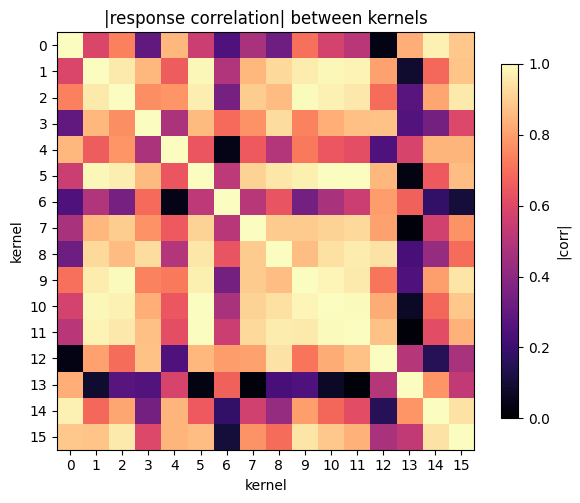

In [8]:
# =====================================================================
# Kernel de-duplication (1/3): response-correlation similarity matrix.
# =====================================================================
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

MERGE_MAX_PATCHES = 400      # training patches used to estimate response correlation
MERGE_QUALITY_TOL = 0.005    # allowed drop in val AUC / tuned val ACC vs the full bank


@torch.no_grad()
def kernel_response_matrix(x_t, kernels_t, max_patches=MERGE_MAX_PATCHES, batch_size=BATCH_SIZE):
    """[K, N*H*W] flattened conv responses over a deterministic patch subsample."""
    n_total = x_t.shape[0]
    n = min(int(max_patches), n_total)
    idx = np.linspace(0, n_total - 1, n).astype(np.int64)
    kt = kernels_t.to(DEVICE)
    chunks = []
    for i in range(0, n, batch_size):
        xb = x_t[idx[i : i + batch_size]].to(DEVICE, non_blocking=True)
        conv = F.conv2d(xb, kt[:, None], padding=kt.shape[-1] // 2)
        chunks.append(conv.permute(1, 0, 2, 3).reshape(kt.shape[0], -1).cpu().numpy())
    return np.concatenate(chunks, axis=1).astype(np.float32)


resp_mat = kernel_response_matrix(X_train_t, kernels_best_t)
corr = np.nan_to_num(np.corrcoef(resp_mat), nan=0.0)
abs_corr = np.abs(corr)
np.fill_diagonal(abs_corr, 1.0)

K0 = corr.shape[0]
offdiag = abs_corr[np.triu_indices(K0, k=1)]
print(f"Response correlation for {K0} kernels from {resp_mat.shape[1]:,} response samples")
print(f"|corr| off-diagonal: min={offdiag.min():.3f} mean={offdiag.mean():.3f} max={offdiag.max():.3f}")

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
im = ax.imshow(abs_corr, cmap="magma", vmin=0.0, vmax=1.0)
ax.set_title("|response correlation| between kernels")
ax.set_xlabel("kernel")
ax.set_ylabel("kernel")
ax.set_xticks(range(K0))
ax.set_yticks(range(K0))
fig.colorbar(im, ax=ax, shrink=0.85, label="|corr|")
plt.tight_layout()
plt.show()

Full bank (K=16): val_auc=0.9388 val_acc_tuned=0.8914 test_auc=0.9411 test_acc_tuned=0.8749



K'=16 | val_auc=0.9389 val_acc_tuned=0.8909 test_auc=0.9411 test_acc_tuned=0.8749


K'=15 | val_auc=0.9390 val_acc_tuned=0.8904 test_auc=0.9409 test_acc_tuned=0.8738


K'=14 | val_auc=0.9389 val_acc_tuned=0.8909 test_auc=0.9410 test_acc_tuned=0.8749


K'=13 | val_auc=0.9388 val_acc_tuned=0.8909 test_auc=0.9412 test_acc_tuned=0.8759


...

K'= 5 | val_auc=0.9292 val_acc_tuned=0.8765 test_auc=0.9356 test_acc_tuned=0.8610


K'= 4 | val_auc=0.9295 val_acc_tuned=0.8781 test_auc=0.9349 test_acc_tuned=0.8599


K'= 3 | val_auc=0.9269 val_acc_tuned=0.8727 test_auc=0.9336 test_acc_tuned=0.8540


K'= 2 | val_auc=0.9259 val_acc_tuned=0.8695 test_auc=0.9326 test_acc_tuned=0.8540


K'= 1 | val_auc=0.9271 val_acc_tuned=0.8674 test_auc=0.9346 test_acc_tuned=0.8481

Chosen minimal distinct kernels: K'=9 (tolerance=0.005 on val AUC & tuned val ACC)


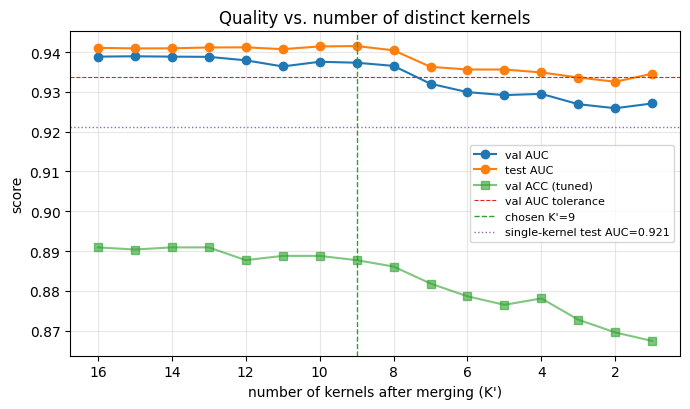

In [9]:
# =====================================================================
# Kernel de-duplication (2/3): cluster, merge, and sweep K' = K..1.
# =====================================================================
def kernels_from_full_profiles(f_full_np):
    ft = torch.from_numpy(np.asarray(f_full_np, dtype=np.float32)).to(DEVICE)
    return torch.einsum("kr,rhw->khw", ft, basis_t).detach().cpu().numpy().astype(np.float32)


def merge_profiles_by_labels(f_full_np, labels, corr_mat):
    """Merge each cluster into one sign-aligned, norm-matched radial profile."""
    labels = np.asarray(labels)
    merged, groups = [], []
    for lab in sorted(set(labels.tolist())):
        members = np.where(labels == lab)[0].tolist()
        ref = members[int(np.argmax([np.abs(corr_mat[m, members]).sum() for m in members]))]
        acc = np.zeros(f_full_np.shape[1], dtype=np.float64)
        for m in members:
            acc += (1.0 if corr_mat[ref, m] >= 0 else -1.0) * f_full_np[m]
        acc /= len(members)
        target_norm = float(np.mean([np.linalg.norm(f_full_np[m]) for m in members]))
        nrm = float(np.linalg.norm(acc))
        if nrm > 1e-8:
            acc = acc / nrm * target_norm
        merged.append(acc.astype(np.float32))
        groups.append(members)
    return np.stack(merged, axis=0).astype(np.float32), groups


def evaluate_kernel_bank(kernels_np):
    """Refit the same balanced logistic head on a kernel bank and score it."""
    kt = torch.from_numpy(np.asarray(kernels_np, dtype=np.float32)).to(DEVICE)
    tr = extract_bank_features(X_train_t, kt, BATCH_SIZE)
    va = extract_bank_features(X_val_t, kt, BATCH_SIZE)
    te = extract_bank_features(X_test_t, kt, BATCH_SIZE)
    mu = tr.mean(axis=0)
    sd = np.where(tr.std(axis=0) > 1e-8, tr.std(axis=0), 1.0)
    clf = LogisticRegression(max_iter=2000, class_weight="balanced")
    clf.fit((tr - mu) / sd, y_train)
    vap = clf.predict_proba((va - mu) / sd)[:, 1]
    tep = clf.predict_proba((te - mu) / sd)[:, 1]
    thr, _ = best_threshold_by_accuracy(y_val, vap, THRESHOLD_GRID_SIZE)
    return {
        "val_auc": metrics_from_probs(y_val, vap, 0.5)["auc"],
        "val_acc": metrics_from_probs(y_val, vap, 0.5)["acc"],
        "val_acc_tuned": metrics_from_probs(y_val, vap, thr)["acc"],
        "test_auc": metrics_from_probs(y_test, tep, 0.5)["auc"],
        "test_acc": metrics_from_probs(y_test, tep, 0.5)["acc"],
        "test_acc_tuned": metrics_from_probs(y_test, tep, thr)["acc"],
        "threshold": float(thr), "clf": clf, "mu": mu.astype(np.float32), "sd": sd.astype(np.float32),
    }


dist = 1.0 - abs_corr
dist = 0.5 * (dist + dist.T)
np.fill_diagonal(dist, 0.0)
Z = linkage(squareform(dist, checks=False), method="average")

baseline = evaluate_kernel_bank(kernel_best)
print(f"Full bank (K={K0}): val_auc={baseline['val_auc']:.4f} "
      f"val_acc_tuned={baseline['val_acc_tuned']:.4f} "
      f"test_auc={baseline['test_auc']:.4f} test_acc_tuned={baseline['test_acc_tuned']:.4f}\n")

sweep, seen_k = [], set()
for target in range(K0, 0, -1):
    labels = fcluster(Z, t=target, criterion="maxclust")
    kp = int(labels.max())
    if kp in seen_k:
        continue
    seen_k.add(kp)
    f_merged, groups = merge_profiles_by_labels(f_best_full, labels, corr)
    ev = evaluate_kernel_bank(kernels_from_full_profiles(f_merged))
    ev.update({"k": kp, "labels": labels, "f_merged": f_merged, "groups": groups})
    sweep.append(ev)
    print(f"K'={kp:2d} | val_auc={ev['val_auc']:.4f} val_acc_tuned={ev['val_acc_tuned']:.4f} "
          f"test_auc={ev['test_auc']:.4f} test_acc_tuned={ev['test_acc_tuned']:.4f}")
sweep.sort(key=lambda d: d["k"])

eligible = [s for s in sweep
            if s["val_auc"] >= baseline["val_auc"] - MERGE_QUALITY_TOL
            and s["val_acc_tuned"] >= baseline["val_acc_tuned"] - MERGE_QUALITY_TOL]
chosen = min(eligible, key=lambda d: d["k"]) if eligible else max(sweep, key=lambda d: d["k"])
print(f"\nChosen minimal distinct kernels: K'={chosen['k']} "
      f"(tolerance={MERGE_QUALITY_TOL} on val AUC & tuned val ACC)")

ks = [s["k"] for s in sweep]
fig, ax = plt.subplots(1, 1, figsize=(7, 4.2))
ax.plot(ks, [s["val_auc"] for s in sweep], "-o", label="val AUC")
ax.plot(ks, [s["test_auc"] for s in sweep], "-o", label="test AUC")
ax.plot(ks, [s["val_acc_tuned"] for s in sweep], "-s", alpha=0.6, label="val ACC (tuned)")
ax.axhline(baseline["val_auc"] - MERGE_QUALITY_TOL, color="tab:red", ls="--", lw=0.8, label="val AUC tolerance")
ax.axvline(chosen["k"], color="tab:green", ls="--", lw=1.0, label=f"chosen K'={chosen['k']}")
if single_kernel_best is not None:
    ax.axhline(single_kernel_best["test_auc"], color="tab:purple", ls=":", lw=1.0,
               label=f"single-kernel test AUC={single_kernel_best['test_auc']:.3f}")
ax.set_xlabel("number of kernels after merging (K')")
ax.set_ylabel("score")
ax.set_title("Quality vs. number of distinct kernels")
ax.invert_xaxis()
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Kernel reduction: 16 -> 9 kernels (44% fewer)
------------------------------------------------------------------
metric                   full(16)       reduced(9)     delta
val AUC                    0.9388           0.9373   -0.0015
val ACC*                   0.8914           0.8877   -0.0037
test AUC                   0.9411           0.9415   +0.0005
test ACC*                  0.8749           0.8733   -0.0016
* accuracy at the validation-tuned threshold

Versus best saved single-kernel run:
metric              single   full bank   reduced
test AUC            0.9212      0.9411    0.9415
test ACC@0.5        0.8524      0.8754    0.8727
test ACC@thr        0.8412      0.8749    0.8733

Merge groups (original kernel indices -> reduced kernel):
  reduced[0] <- [0, 14]
  reduced[1] <- [15]
  reduced[2] <- [4]
  reduced[3] <- [13]
  reduced[4] <- [8, 12]
  reduced[5] <- [3]
  reduced[6] <- [1, 2, 5, 9, 10, 11]
  reduced[7] <- [7]
  reduced[8] <- [6]


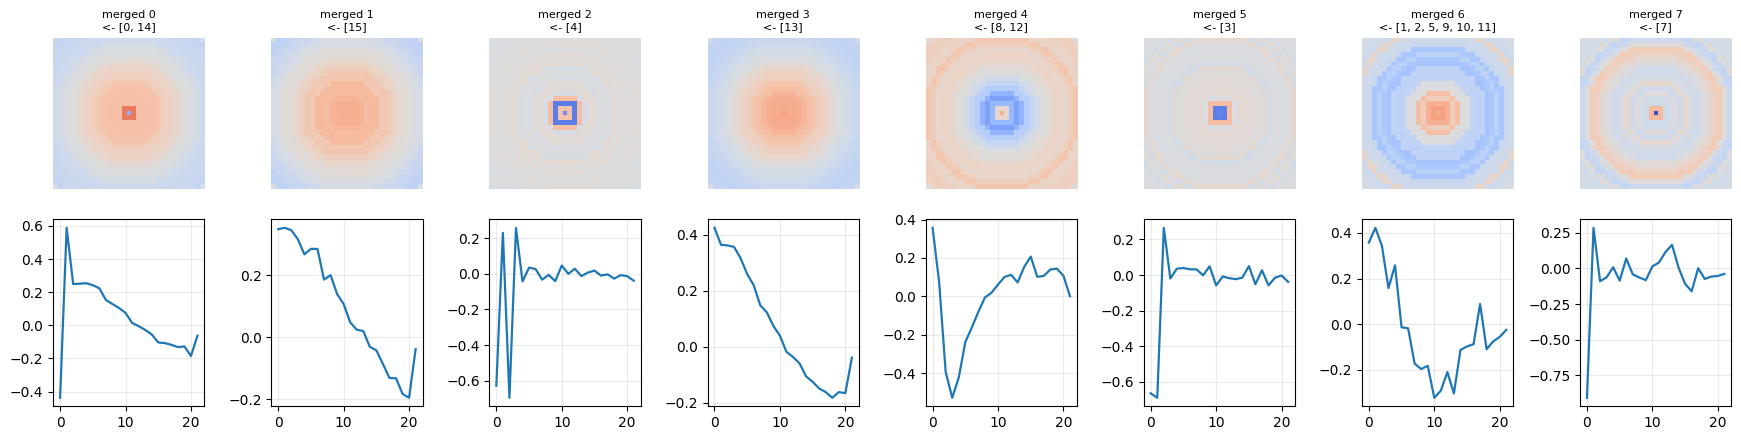


Saved reduced kernel bank (9 kernels) and summary to results/exp_022_mmr_nperFamily500_nComposition1250/radial_kernel_bank_k16_r20


In [10]:
# =====================================================================
# Kernel de-duplication (3/3): finalize reduced bank, compare, save.
# =====================================================================
f_reduced_full = chosen["f_merged"].astype(np.float32)
kernel_reduced = kernels_from_full_profiles(f_reduced_full).astype(np.float32)
reduced_eval = evaluate_kernel_bank(kernel_reduced)

print("=" * 66)
print(f"Kernel reduction: {K0} -> {chosen['k']} kernels ({100.0 * (1 - chosen['k'] / K0):.0f}% fewer)")
print("-" * 66)
print(f"{'metric':<18}{'full(' + str(K0) + ')':>15}{'reduced(' + str(chosen['k']) + ')':>17}{'delta':>10}")
for key, label in [("val_auc", "val AUC"), ("val_acc_tuned", "val ACC*"),
                   ("test_auc", "test AUC"), ("test_acc_tuned", "test ACC*")]:
    b, r = baseline[key], reduced_eval[key]
    print(f"{label:<18}{b:>15.4f}{r:>17.4f}{r - b:>+10.4f}")
print("* accuracy at the validation-tuned threshold")

if single_kernel_best is not None:
    print("\nVersus best saved single-kernel run:")
    print(f"{'metric':<16}{'single':>10}{'full bank':>12}{'reduced':>10}")
    print(f"{'test AUC':<16}{single_kernel_best['test_auc']:>10.4f}"
          f"{baseline['test_auc']:>12.4f}{reduced_eval['test_auc']:>10.4f}")
    print(f"{'test ACC@0.5':<16}{single_kernel_best['test_acc']:>10.4f}"
          f"{baseline['test_acc']:>12.4f}{reduced_eval['test_acc']:>10.4f}")
    print(f"{'test ACC@thr':<16}{single_kernel_best['test_acc_tuned']:>10.4f}"
          f"{baseline['test_acc_tuned']:>12.4f}{reduced_eval['test_acc_tuned']:>10.4f}")

print("\nMerge groups (original kernel indices -> reduced kernel):")
for j, members in enumerate(chosen["groups"]):
    print(f"  reduced[{j}] <- {members}")

Kp = chosen["k"]
n_show = min(Kp, 8)
fig, axes = plt.subplots(2, n_show, figsize=(2.2 * n_show, 4.6))
if n_show == 1:
    axes = np.array(axes).reshape(2, 1)
vmax = float(np.max(np.abs(kernel_reduced))) + 1e-12
for j in range(n_show):
    axes[0, j].imshow(kernel_reduced[j], cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axes[0, j].set_title(f"merged {j}\n<- {chosen['groups'][j]}", fontsize=8)
    axes[0, j].axis("off")
    axes[1, j].plot(np.arange(f_reduced_full.shape[1]), f_reduced_full[j], lw=1.6)
    axes[1, j].grid(alpha=0.25)
plt.tight_layout()
plt.show()

if SAVE_ARTIFACTS:
    np.save(OUT_DIR / "kernels_reduced_radial_bank.npy", kernel_reduced)
    np.save(OUT_DIR / "f_reduced_full_bank.npy", f_reduced_full)
    reduce_summary = {
        "num_kernels_full": int(K0),
        "num_kernels_reduced": int(Kp),
        "quality_tolerance": float(MERGE_QUALITY_TOL),
        "similarity": "abs_response_correlation",
        "linkage": "average",
        "baseline_metrics": {k: float(baseline[k]) for k in
                             ("val_auc", "val_acc", "val_acc_tuned", "test_auc", "test_acc", "test_acc_tuned")},
        "reduced_metrics": {k: float(reduced_eval[k]) for k in
                            ("val_auc", "val_acc", "val_acc_tuned", "test_auc", "test_acc", "test_acc_tuned")},
        "best_published_single_kernel": single_kernel_best,
        "merge_groups": [[int(m) for m in g] for g in chosen["groups"]],
        "sweep": [{"k": int(s["k"]), "val_auc": float(s["val_auc"]),
                   "val_acc_tuned": float(s["val_acc_tuned"]),
                   "test_auc": float(s["test_auc"]),
                   "test_acc_tuned": float(s["test_acc_tuned"])} for s in sweep],
    }
    (OUT_DIR / "kernel_reduction_summary.json").write_text(json.dumps(reduce_summary, indent=2))
    print(f"\nSaved reduced kernel bank ({Kp} kernels) and summary to {OUT_DIR}")

Rendering reduced-bank heatmap (K'=9) for data/TIFF Images/malignantAnnotation/IMG015.tif


  rows 8/188


  rows 16/188


  rows 24/188


  rows 32/188


...

  rows 160/188


  rows 168/188


  rows 176/188


  rows 184/188


  rows 188/188


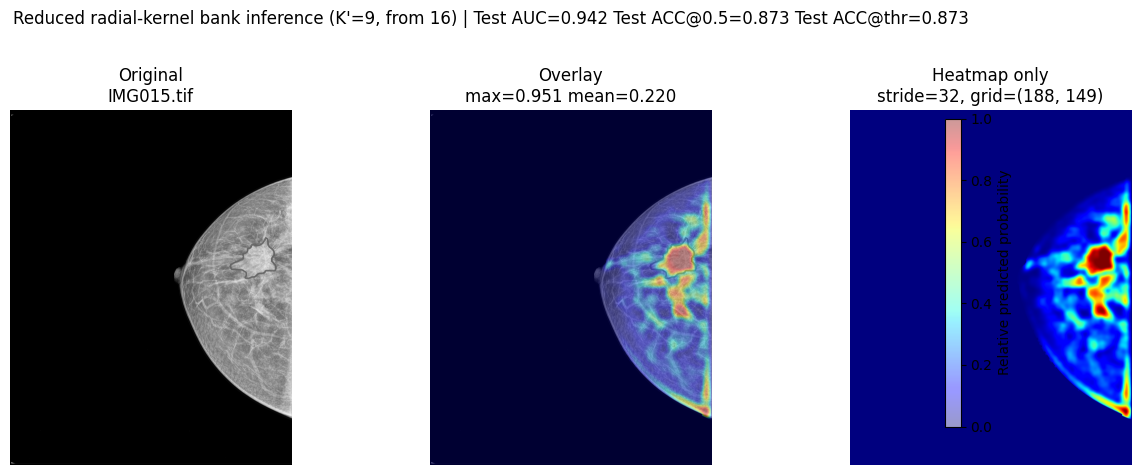

Saved reduced-bank heatmap artifacts to results/exp_022_mmr_nperFamily500_nComposition1250/radial_kernel_bank_k16_r20


In [11]:
# =====================================================================
# Full-image inference heatmap for the REDUCED kernel bank.
# Same pipeline as above, scored with the reduced kernels and their refit logistic head.
# =====================================================================
if RUN_HEATMAP:
    reduced_clf = reduced_eval["clf"]
    example_path = ensure_example_image(EXAMPLE_IMAGE_PATH)
    print(f"Rendering reduced-bank heatmap (K'={chosen['k']}) for {example_path}")
    fig_red, prob_map_red, prob_grid_red = render_bank_heatmap(
        example_path,
        kernel_reduced,
        reduced_eval["mu"],
        reduced_eval["sd"],
        reduced_clf.coef_[0].astype(np.float32),
        float(reduced_clf.intercept_[0]),
        title=(f"Reduced radial-kernel bank inference (K'={chosen['k']}, from {K0}) | "
               f"Test AUC={reduced_eval['test_auc']:.3f} "
               f"Test ACC@0.5={reduced_eval['test_acc']:.3f} "
               f"Test ACC@thr={reduced_eval['test_acc_tuned']:.3f}"),
    )
    if SAVE_ARTIFACTS:
        fig_red.savefig(OUT_DIR / f"{example_path.stem}_reduced_bank_heatmap.png", dpi=200, bbox_inches="tight")
        np.save(OUT_DIR / f"{example_path.stem}_reduced_bank_prob_grid.npy", prob_grid_red)
        print(f"Saved reduced-bank heatmap artifacts to {OUT_DIR}")
else:
    print("RUN_HEATMAP=False -- skipping reduced-bank full-image inference.")